In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import pandas as pd
import skimage
import scipy
import sklearn.metrics

filenames        C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype.tif
datasets                                             screen
magnification                                            14
micron                                                 4.25
split                                            validation
Name: 15, dtype: object


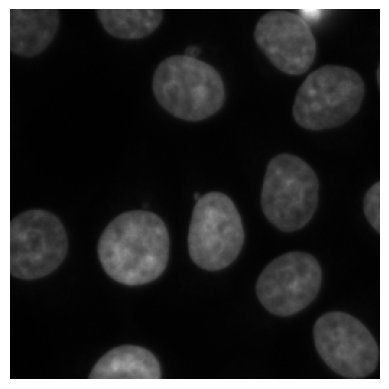

In [3]:
metadata = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
screen = metadata[metadata.datasets == 'screen']
print(screen.iloc[3])

im = skimage.io.imread(f'/scr/yren/all_data_micronuclei/{screen.iloc[3]['split']}/{screen.iloc[3]['filenames']}')
gt = skimage.io.imread(f'/scr/yren/all_data_micronuclei/{screen.iloc[3]['split']}/{screen.iloc[3]['filenames'].replace('.phenotype.tif', '.phenotype_outlines.png')}')

ys, xs = np.where(gt == 32)
y, x = int(np.mean(ys)), int(np.mean(xs))
y, x

patch = 128
plt.imshow(im[y-patch:y+patch, x-patch:x+patch], cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
fig, ax = plt.subplots()

# Display the image
ax.imshow(im[y-patch:y+patch, x-patch:x+patch], cmap='gray')

# Add grid lines
ax.grid(True, color='white')

plt.show()

In [ ]:
crop = im[y-patch:y+patch, x-patch:x+patch]
print(crop.shape)
H, W = crop.shape
PS = 50
patches_per_image = (W // PS) * (H // PS)
print(f'height - {H}, width - {W}, patches - {patches_per_image}')
X = np.linspace(0, W - W % PS, W // PS + 1)
Y = np.linspace(0, H - H % PS, H // PS + 1)
X,Y = np.meshgrid(X[:-1],Y[:-1], indexing='ij')
X = X.reshape((patches_per_image,))
Y = Y.reshape((patches_per_image,))
C = np.stack((Y,X)).T

coords = C[0:9]

fig, ax = plt.subplots(1,9, figsize=(10,10))
for i in range(len(coords)):
    coord = coords[i]
    r, c = int(coord[0]), int(coord[1])
    image = crop[r:r+PS, c:c+PS]
    ax[i].imshow(image)

    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].axis('off')
plt.show()
    

# Analysis on 47 validation images

# Swarmplot

In [51]:
with open('/scr/yren/plot_data/swarmplot_nonscaled_DinoMN_pred.txt', 'r') as f:
    lines = [line.rstrip('\n') for line in f.readlines()]

lines

['2022-05-26_RPE1-2198,0.8966,0.6903',
 '2022-10-14_U2OS-1,0.8627,0.6984',
 '2023-05-31_misc-4,0.6667,1.0000',
 '20X_c0-DAPI_A1_Tile-50,0.7824,0.9264',
 'C1-20X_c0_B3_Tile-24,0.7273,0.9577',
 'C1-20X_c0_phalloidin_C3_Tile-15,0.7812,0.9615',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5,0.6903,0.9398',
 'C2-20X_c0-DAPI-GFP_B3_Tile-16,0.8261,0.9500',
 'IXMtest_B04_s4_w1F6AEFA0F-AF87-4B3B-A334-698647CFE043,0.5833,0.7778',
 'IXMtest_B12_s2_w19F7E0279-D087-4B5E-9899-61971C29CB78,0.5385,0.7000',
 'IXMtest_B19_s7_w1E43B84DB-39E2-4BFB-8CB4-554B32098C75,0.4444,0.5714',
 'IXMtest_B24_s9_w18C4FE0DD-12CA-4711-9722-3E3105D1E691,0.2857,0.8000',
 'IXMtest_C18_s1_w11C16FC59-2E29-496A-803A-89581FDF538A,0.6667,0.8333',
 'IXMtest_D02_s8_w1AC6783DF-ED35-4818-8091-E6D02AF4BFBD,0.6957,1.0000',
 'IXMtest_D07_s4_w16CF58D03-0B05-41FE-AE73-7298887DEBB1,0.6667,1.0000',
 'IXMtest_D19_s6_w1EB1F11AE-4FB6-481F-94D9-40246870F0CB,0.8750,0.6364',
 'IXMtest_E06_s3_w1701573EB-CE9A-4D76-8668-0416996E1DCD,0.5455,0.6667',
 'IXMtest_E12_s9

In [52]:
data = [line.strip().split(',') for line in lines]  # Strip to remove any trailing newlines
metrics = pd.DataFrame(data, columns=['imid', 'precision', 'recall'])
# Convert 'precision' and 'recall' to float
metrics[['precision', 'recall']] = metrics[['precision', 'recall']].astype(float)
metrics['model'] = 'model_v3'

In [53]:
metrics.head()

,imid,precision,recall,model
0,2022-05-26_RPE1-2198,0.8966,0.6903,model_v3
1,2022-10-14_U2OS-1,0.8627,0.6984,model_v3
2,2023-05-31_misc-4,0.6667,1.0000,model_v3
3,20X_c0-DAPI_A1_Tile-50,0.7824,0.9264,model_v3
4,C1-20X_c0_B3_Tile-24,0.7273,0.9577,model_v3


In [54]:
with open('/scr/yren/plot_data/swarmplot_nonscaled_MNFinder_pred.txt', 'r') as f:
    lines_mnfinder = [line.rstrip('\n') for line in f.readlines()]
lines_mnfinder[0:3]

['IXMtest_P15_s3_w10F5E9699-743C-4177-93CE-27CFD65A925E,0.85714286,0.75',
 'IXMtest_O16_s2_w1F6F6A3A1-99E4-4029-B734-022806CF6D42,0.83333333,0.5',
 'IXMtest_O09_s2_w133C7EDCE-1C7C-41A6-9E52-7AD499E7CDC8,0.8,0.88888889']

In [55]:
data_mnfinder = [line.strip().split(',') for line in lines_mnfinder]  # Strip to remove any trailing newlines
metrics_mnfinder = pd.DataFrame(data_mnfinder, columns=['imid', 'precision', 'recall'])
# Convert 'precision' and 'recall' to float
metrics_mnfinder[['precision', 'recall']] = metrics_mnfinder[['precision', 'recall']].astype(float)
metrics_mnfinder['model'] = 'mnfinder'
metrics_mnfinder.head()

,imid,precision,recall,model
0,IXMtest_P15_s3_w10F5E9699-743C-4177-93CE-27CFD...,0.857143,0.750000,mnfinder
1,IXMtest_O16_s2_w1F6F6A3A1-99E4-4029-B734-02280...,0.833333,0.500000,mnfinder
2,IXMtest_O09_s2_w133C7EDCE-1C7C-41A6-9E52-7AD49...,0.800000,0.888889,mnfinder
3,IXMtest_N18_s2_w1CC5ED51D-86C5-437D-8EDD-E56E4...,0.666667,0.666667,mnfinder
4,IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1...,0.692308,0.692308,mnfinder


In [56]:
with open('/scr/yren/plot_data/swarmplot_nonscaled_Cellpose_pred.txt', 'r') as f:
    lines_cellpose = [line.rstrip('\n') for line in f.readlines()]
lines_cellpose[0:3]

['IXMtest_P15_s3_w10F5E9699-743C-4177-93CE-27CFD65A925E,0.75,0.375',
 'IXMtest_O16_s2_w1F6F6A3A1-99E4-4029-B734-022806CF6D42,1,0.5',
 'IXMtest_O09_s2_w133C7EDCE-1C7C-41A6-9E52-7AD499E7CDC8,1,0.11111111']

In [57]:
data_cellpose = [line.strip().split(',') for line in lines_cellpose]  # Strip to remove any trailing newlines
metrics_cellpose = pd.DataFrame(data_cellpose, columns=['imid', 'precision', 'recall'])
# Convert 'precision' and 'recall' to float
metrics_cellpose[['precision', 'recall']] = metrics_cellpose[['precision', 'recall']].astype(float)
metrics_cellpose['model'] = 'cellpose'
metrics_cellpose.head()

,imid,precision,recall,model
0,IXMtest_P15_s3_w10F5E9699-743C-4177-93CE-27CFD...,0.75,0.375000,cellpose
1,IXMtest_O16_s2_w1F6F6A3A1-99E4-4029-B734-02280...,1.00,0.500000,cellpose
2,IXMtest_O09_s2_w133C7EDCE-1C7C-41A6-9E52-7AD49...,1.00,0.111111,cellpose
3,IXMtest_N18_s2_w1CC5ED51D-86C5-437D-8EDD-E56E4...,0.75,0.333333,cellpose
4,IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1...,0.60,0.230769,cellpose


In [58]:
df = pd.concat([metrics, metrics_mnfinder, metrics_cellpose], ignore_index=True)
df

,imid,precision,recall,model
0,2022-05-26_RPE1-2198,0.896600,0.690300,model_v3
1,2022-10-14_U2OS-1,0.862700,0.698400,model_v3
2,2023-05-31_misc-4,0.666700,1.000000,model_v3
3,20X_c0-DAPI_A1_Tile-50,0.782400,0.926400,model_v3
4,C1-20X_c0_B3_Tile-24,0.727300,0.957700,model_v3
...,...,...,...,...
136,C1-20X_c0_B3_Tile-24,0.615385,0.169014,cellpose
137,20X_c0-DAPI_A1_Tile-50,0.781250,0.153374,cellpose
138,2023-05-31_misc-4,1.000000,0.500000,cellpose
139,2022-10-14_U2OS-1,0.272727,0.047619,cellpose


In [61]:
print(df[df.model == 'model_v3']['precision'].max())
print(df[df.model == 'mnfinder']['precision'].max())
print(df[df.model == 'cellpose']['precision'].max())

0.8966
1.0
1.0


/tmp/ipykernel_229842/3883583831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df, x='recall', y='model', palette='bright')


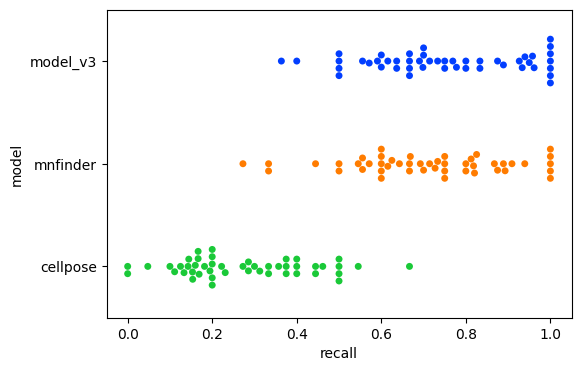

In [62]:
plt.figure(figsize=(6, 4))
sns.swarmplot(data=df, x='recall', y='model', palette='bright')
plt.show()

/tmp/ipykernel_229842/1603537297.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df, x='precision', y='model', palette='bright')


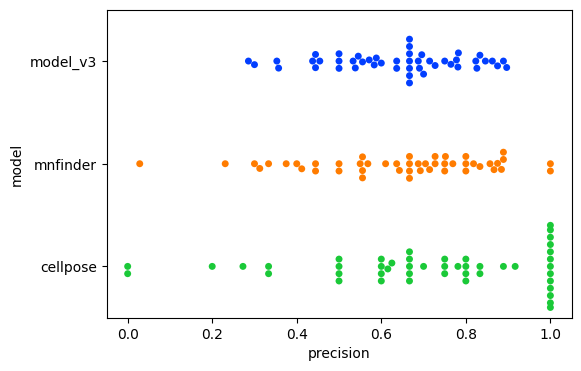

In [63]:
plt.figure(figsize=(6, 4))
sns.swarmplot(data=df, x='precision', y='model', palette='bright')
plt.show()

In [26]:
df[df.model=='model_v3'].head()

,imid,precision,recall,model
0,2022-05-26_RPE1-2198,0.9596,0.8407,model_v3
1,2022-10-14_U2OS-1,0.8182,0.8571,model_v3
2,2023-05-31_misc-4,0.5714,1.0000,model_v3
3,20X_c0-DAPI_A1_Tile-50,0.7967,0.8896,model_v3
4,C1-20X_c0_B3_Tile-24,0.7068,0.9507,model_v3


In [27]:
df[df.model=='mnfinder'].head()

,imid,precision,recall,model
0,2022-05-26_RPE1-2198,0.7328,0.7589,mnfinder
1,2022-10-14_U2OS-1,0.7447,0.5738,mnfinder
2,2023-05-31_misc-4,0.6667,1.0000,mnfinder
3,20X_c0-DAPI_A1_Tile-50,0.7517,0.6687,mnfinder
4,C1-20X_c0_B3_Tile-24,0.6100,0.8652,mnfinder


# IoU Analysis Example

In [16]:
def compare_two_labels(label_model, label_gt, return_IoU_matrix, debug=False):
    
    # get number of detected nuclei
    nb_nuclei_gt = np.max(label_gt)
    nb_nuclei_model = np.max(label_model)
    
    # catch the case of an empty picture in model and gt
    if nb_nuclei_gt == 0 and nb_nuclei_model == 0:
        if(return_IoU_matrix):
            return [0, 0, 1, np.empty(0)]     
        else:
            return [0, 0, 1]
    
    # catch the case of empty picture in model
    if nb_nuclei_model == 0:
        if(return_IoU_matrix):
            return [0, nb_nuclei_gt, 0, np.empty(0)]     
        else:
            return [0, nb_nuclei_gt, 0]
    
    # catch the case of empty picture in gt
    if nb_nuclei_gt == 0:
        if(return_IoU_matrix):
            return [nb_nuclei_model, 0, 0, np.empty(0)]     
        else:
            return [nb_nuclei_model, 0, 0]
    
    # build IoU matrix
    IoUs = np.full((nb_nuclei_gt, nb_nuclei_model), -1.0, dtype = np.float32)

    # calculate IoU for each nucleus index_gt in GT and nucleus index_pred in prediction    
    # TODO improve runtime of this algorithm
    for index_gt in range(1,nb_nuclei_gt+1):

        nucleus_gt = label_gt == index_gt
        number_gt = np.sum(nucleus_gt)

        for index_model in range(1,nb_nuclei_model+1):
            
            if debug:
                print(index_gt, "/", index_model)
            
            nucleus_model = label_model == index_model 
            number_model = np.sum(nucleus_model)
            
            same_and_1 = np.sum((nucleus_gt == nucleus_model) * nucleus_gt)
            
            IoUs[index_gt-1,index_model-1] = same_and_1 / (number_gt + number_model - same_and_1)
    
    # get matches and errors
    detection_map = (IoUs > 0.5)
    nb_matches = np.sum(detection_map)

    detection_rate = IoUs * detection_map
    
    nb_overdetection = nb_nuclei_model - nb_matches
    nb_underdetection = nb_nuclei_gt - nb_matches
    
    mean_IoU = np.mean(np.sum(detection_rate, axis = 1))
    
    if(return_IoU_matrix):
        result = [nb_overdetection, nb_underdetection, mean_IoU, IoUs]
    else:
        result = [nb_overdetection, nb_underdetection, mean_IoU]
    return result


In [17]:
def measures_at(threshold, IOU):
    matches = IOU > threshold
    
    true_positives = np.sum(matches, axis=1) == 1   # Correct objects
    false_positives = np.sum(matches, axis=0) == 0  # Extra objects
    false_negatives = np.sum(matches, axis=1) == 0  # Missed objects
    
    assert np.all(np.less_equal(true_positives, 1))
    assert np.all(np.less_equal(false_positives, 1))
    assert np.all(np.less_equal(false_negatives, 1))
    
    TP, FP, FN = np.sum(true_positives), np.sum(false_positives), np.sum(false_negatives)
    
    f1 = 2*TP / (2*TP + FP + FN + 1e-9)

    prec = TP / (TP + FP)

    rec = TP / (TP + FN)

    return f1, prec, rec, TP, FP, FN

# Save 47 Probabilities & IoUs

In [29]:
import os
import sys
sys.path.append('../')
import time
import torch
import skimage
import sklearn.metrics
import wandb

import numpy as np
import matplotlib.pyplot as plt

from microdet import mnds

In [30]:
# Hyperparameters
DIRECTORY = '/scr/yren/plot_data/all_data_predictions_no_rescale/'
SCALE_FACTOR = 1.0
THRESHOLD = 0.5

In [31]:
filelist = os.listdir(DIRECTORY)
files = [file for file in filelist if file.endswith('_probabilities.npy')]
print(len(files)) # 47 expected

47


In [32]:
im = np.load(DIRECTORY + files[0])
print(im.shape)

(768, 869)


In [33]:
for file in files:
    imid = file.split('.')[0]
    prob = np.load(DIRECTORY + file)
    mn_pred = prob > THRESHOLD
    mn_gt = mnds.read_image('/scr/yren/all_data_micronuclei_no_rescale/validation', imid, 'phenotype_outlines.png', scale=SCALE_FACTOR)
    
    pi = skimage.morphology.label(mn_pred)
    gti = skimage.morphology.label(mn_gt)
    nb_overdetection, nb_underdetection, mean_IoU, IoUs = compare_two_labels(pi, gti, True)
    
    matches = IoUs > 0.1
    for i in range(0, matches.shape[0]):
        if (True in matches[i,:]):
            idx = np.where(matches[i,:]==True)[0][0]
            label_gt = i + 1
            label_pred = idx + 1
            
            area_gt = np.sum(gti == label_gt)
            area_pred = np.sum(pi == label_pred)
    
    print(imid, matches.shape, len(np.unique(pi)))

    IoU_filename = f'/scr/yren/plot_data/all_data_IoUs_no_rescale/{imid}._IoUs.npy'
    np.save(IoU_filename, matches)

KeyboardInterrupt: 

## Scatter Plots

In [23]:
IoU_files = os.listdir('/scr/yren/plot_data/all_data_IoUs_no_rescale/')
print(len(IoU_files))
IoU_files

47


['2022-05-26_RPE1-2198._IoUs.npy',
 '2022-10-14_U2OS-1._IoUs.npy',
 '2023-05-31_misc-4._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-50._IoUs.npy',
 'C1-20X_c0_B3_Tile-24._IoUs.npy',
 'C1-20X_c0_phalloidin_C3_Tile-15._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_B3_Tile-16._IoUs.npy',
 'IXMtest_B04_s4_w1F6AEFA0F-AF87-4B3B-A334-698647CFE043._IoUs.npy',
 'IXMtest_B12_s2_w19F7E0279-D087-4B5E-9899-61971C29CB78._IoUs.npy',
 'IXMtest_B19_s7_w1E43B84DB-39E2-4BFB-8CB4-554B32098C75._IoUs.npy',
 'IXMtest_B24_s9_w18C4FE0DD-12CA-4711-9722-3E3105D1E691._IoUs.npy',
 'IXMtest_C18_s1_w11C16FC59-2E29-496A-803A-89581FDF538A._IoUs.npy',
 'IXMtest_D02_s8_w1AC6783DF-ED35-4818-8091-E6D02AF4BFBD._IoUs.npy',
 'IXMtest_D07_s4_w16CF58D03-0B05-41FE-AE73-7298887DEBB1._IoUs.npy',
 'IXMtest_D19_s6_w1EB1F11AE-4FB6-481F-94D9-40246870F0CB._IoUs.npy',
 'IXMtest_G10_s3_w1C1257E17-1DBA-4619-B06E-D6DBB8A53088._IoUs.npy',
 'IXMtest_G13_s9_w19606195E-12B4-46FF-9B83-1F7FE11B3AFB._IoUs.npy',
 'IXMtest_G12_s6

In [26]:
import pandas as pd

df = pd.DataFrame(columns = ['original_area', 'predicted_area', 'status'])

for i in range(len(IoU_files)):
    path = '/scr/yren/plot_data/all_data_IoUs_no_rescale/' + IoU_files[i]
    matches = np.load(path)
    
    imid = IoU_files[i].split('.')[0]
    prob = np.load(f'/scr/yren/plot_data/all_data_predictions_no_rescale/{imid}._probabilities.npy')
    mn_pred = prob > THRESHOLD
    mn_gt = mnds.read_image('/scr/yren/all_data_micronuclei_no_rescale/validation', imid, 'phenotype_outlines.png', scale=SCALE_FACTOR)
    
    pi = skimage.morphology.label(mn_pred)
    gti = skimage.morphology.label(mn_gt)
    
    original_area = []
    predicted_area = []
    status = [] # True/Flase
    
    for j in range(0, matches.shape[0]): # not detected should be 0 for predicted area
        if (True in matches[j,:]):
            idx = np.where(matches[j,:]==True)[0][0]
            label_gt = j + 1
            label_pred = idx + 1
            
            area_gt = np.sum(gti == label_gt)
            area_pred = np.sum(pi == label_pred)
            
            original_area.append(area_gt)
            predicted_area.append(area_pred)
            status.append('Detected') # detected
            
        else: # ground truth is not predicted by the model
            area_gt = np.sum(gti == label_gt)
            area_pred = 0
            
            original_area.append(area_gt)
            predicted_area.append(area_pred)
            status.append('Missed') # not detected
            
    df_single_image = pd.DataFrame({'original_area':original_area, 'predicted_area':predicted_area, 'status':status})
    df = pd.concat([df, df_single_image], ignore_index=True)

In [27]:
df.to_csv('/scr/yren/plot_data/DinoMN_detection.csv')

In [21]:
df

,original_area,predicted_area,status
0,22,0,Missed
1,22,0,Missed
2,91,138,Detected
3,10,24,Detected
4,26,80,Detected
...,...,...,...
1134,96,145,Detected
1135,182,150,Detected
1136,24,165,Detected
1137,24,0,Missed


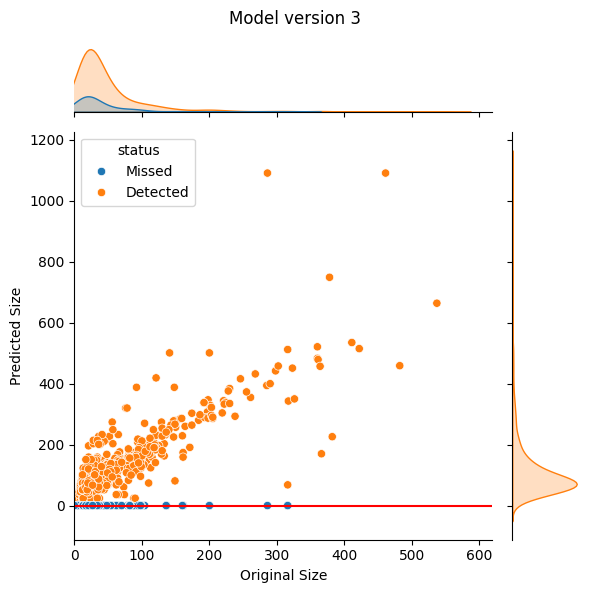

In [ ]:
import seaborn as sns

pilot_figure = sns.jointplot(data=df, x='original_area', y='predicted_area', hue='status')
pilot_figure.figure.suptitle('Model version 3')
plt.axhline(y=0, color='red')
plt.xlabel('Original Size')
plt.ylabel('Predicted Size')
plt.xlim(left=0) 
plt.tight_layout()
plt.show()

In [ ]:
path = '/scr/yren/all_data_micronuclei/validation/'
save_path = '/scr/yren/validation_overlaps/'
overlaps = os.listdir(save_path)

for i in overlaps:
    imid = i.split('.')[0]
    overlap = np.load(save_path + i)
    pred = overlap[:,:,0]
    gt = overlap[:,:,2]
    # view = np.concatenate([255*pred[:,:,None], 255*gt[:,:,None], np.zeros_like(pred)[:,:,None]], axis=2)
    
    original_im = skimage.io.imread(path + i.replace('._overlap.npy', '.phenotype.tif'))
    cut = np.percentile(original_im,0.9)
    view = np.concatenate([255*pred[:,:,None], 255*gt[:,:,None], 255*(original_im[:,:,None]>cut)], axis=2)
    
    print(imid)
    fig, axs = plt.subplots(1,2, figsize=(30,30))
    axs[0].imshow(original_im)
    axs[0].set_title('Input')
    
    # axs[1].imshow(overlap)
    axs[1].imshow(view)
    axs[1].set_title('Overlaps')

    axs[0].axis('off')
    axs[1].axis('off')
    plt.show()
    plt.close('all')
    break
    # time.sleep(1)

# Example of C2-20X_c0-DAPI-GFP_B3_Tile-16

In [2]:
import numpy as np
import pandas as pd
import skimage
import matplotlib.pyplot as plt

In [16]:
our = np.load('/scr/yren/plot_data/all_data_predictions_no_rescale/C2-20X_c0-DAPI-GFP_B3_Tile-16._probabilities.npy')
mnfinder = np.load('/scr/yren/plot_data/mnfinder_predictions_output_no_rescale/C2-20X_c0-DAPI-GFP_B3_Tile-16._probabilities.npy')
cellpose = np.load('/scr/yren/plot_data/cellpose_nonscaled_predictions/C2-20X_c0-DAPI-GFP_B3_Tile-16._probabilities.npy')
gt = skimage.io.imread('/scr/yren/all_data_micronuclei_no_rescale/validation/C2-20X_c0-DAPI-GFP_B3_Tile-16.phenotype_outlines.png')

- process cellpose mask

In [18]:
MICRON_AREA_THRESHOLD = 100
labels = skimage.morphology.label(cellpose)
micron_labels = []
for i in range(1, len(np.unique(labels))):
    area = np.sum(labels == i)
    if area < MICRON_AREA_THRESHOLD:
        micron_labels.append(i)
        
cellpose_micro_mask = np.zeros_like(cellpose)
for i in micron_labels:
    cellpose_micro_mask += (labels == i)

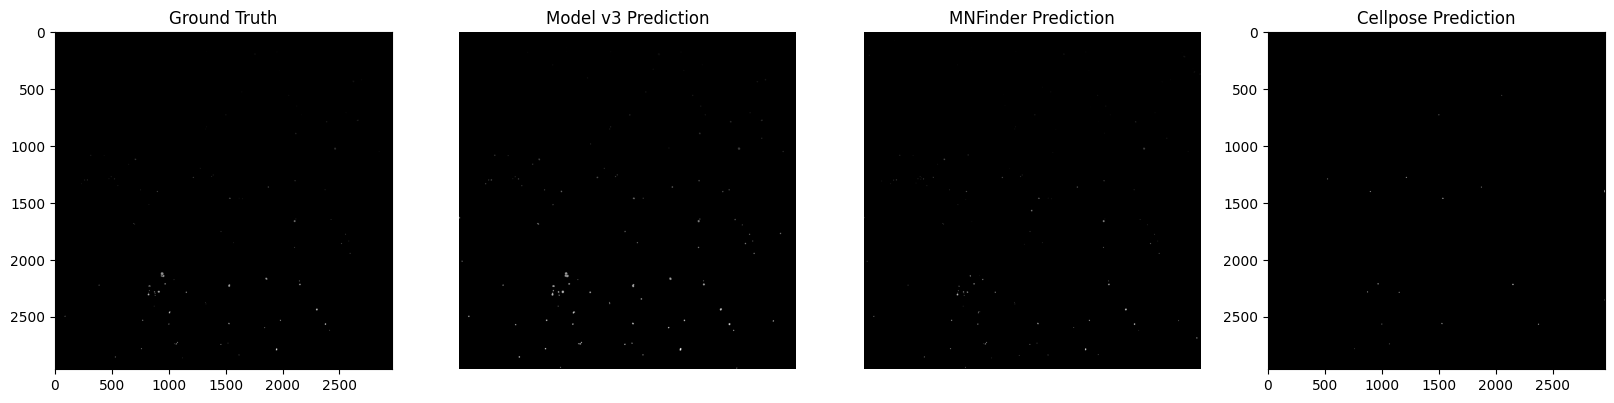

In [26]:

fig, ax = plt.subplots(1, 4, figsize=(20, 20))

ax[0].imshow(gt, cmap='gray')
ax[0].set_title('Ground Truth')
# ax[0].axis('off')  # Remove axes

ax[1].imshow(our, cmap='gray')
ax[1].set_title('Model v3 Prediction')
ax[1].axis('off')  # Remove axes

ax[2].imshow(mnfinder, cmap='gray')
ax[2].set_title('MNFinder Prediction')
ax[2].axis('off')  # Remove axes

ax[3].imshow(cellpose_micro_mask, cmap='gray')
ax[3].set_title('Cellpose Prediction')
# ax[3].axis('off')  # Remove axes

plt.show()

In [34]:
cellpose_labels = skimage.measure.label(cellpose_micro_mask)
coord = []
for i in range(1, len(np.unique(cellpose_labels))):
    a,b = np.where(cellpose_labels == i)
    y,x = int(np.mean(a)), int(np.mean(b))
    coord.append((y,x))

In [35]:
coord

[(556, 2052),
 (727, 1500),
 (1276, 1214),
 (1290, 522),
 (1361, 1873),
 (1397, 2957),
 (1400, 898),
 (1460, 1535),
 (2211, 966),
 (2216, 2151),
 (2282, 873),
 (2286, 1151),
 (2352, 2957),
 (2560, 1527),
 (2564, 999),
 (2566, 2375),
 (2739, 1066),
 (2781, 759)]

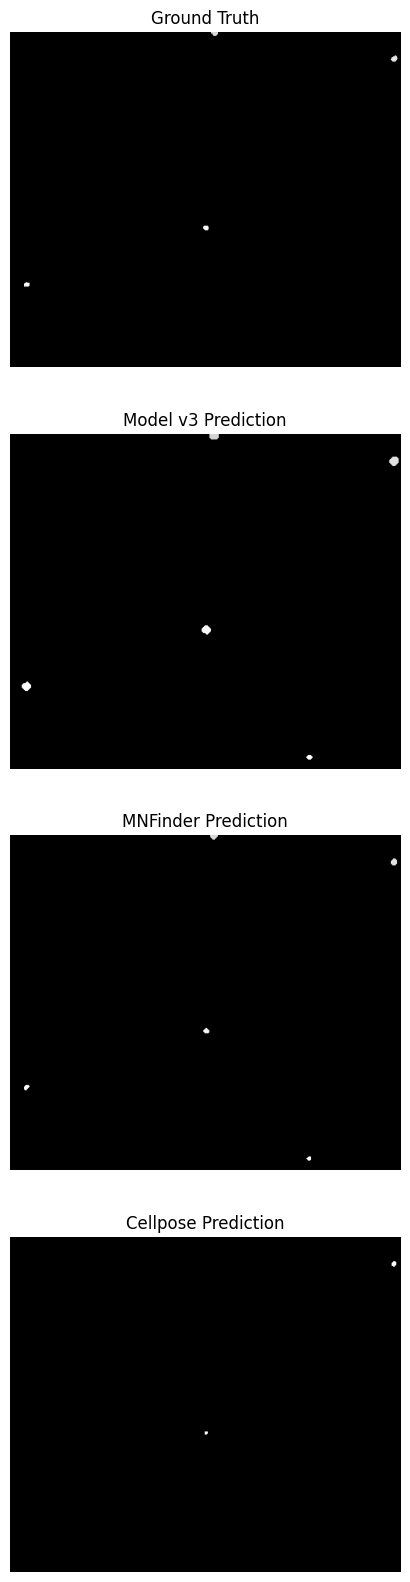

In [47]:
# R = 2000
# C = 700
# P = 256
coord = (2781, 759)
P = 500
R = coord[0] - P//2
C = coord[1] - P//2



fig, ax = plt.subplots(4,1, figsize=(20, 20))

ax[0].imshow(gt[R:R+P, C:C+P], cmap='gray')
ax[0].set_title('Ground Truth')
ax[0].axis('off')  # Remove axes

ax[1].imshow(our[R:R+P, C:C+P], cmap='gray')
ax[1].set_title('Model v3 Prediction')
ax[1].axis('off')  # Remove axes

ax[2].imshow(mnfinder[R:R+P, C:C+P], cmap='gray')
ax[2].set_title('MNFinder Prediction')
ax[2].axis('off')  # Remove axes

ax[3].imshow(cellpose_micro_mask[R:R+P, C:C+P], cmap='gray')
ax[3].set_title('Cellpose Prediction')
ax[3].axis('off')  # Remove axes

plt.show()


In [10]:
prob256 = np.load('/scr/yren/micronuclei-detection/microdet/all_data_micronuclei_no_rescale/validation/model_output/output/C2-20X_c0-DAPI-GFP_B3_Tile-16._probabilities.npy')

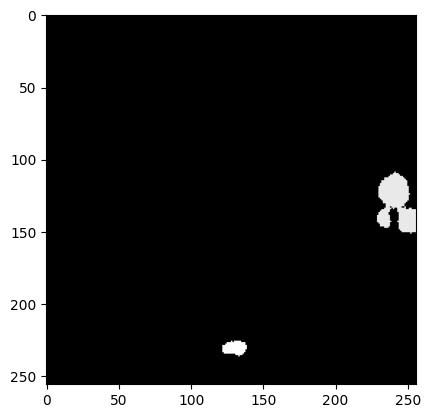

In [11]:
plt.imshow(prob256[R:R+P, C:C+P], cmap='gray')

In [12]:
crop_gt = gt[R:R+P, C:C+P]
print(crop_gt.shape)

(256, 256)


In [20]:
crop_gt2 = skimage.transform.resize(crop_gt, (128,128))
print(crop_gt2.shape)

(128, 128)


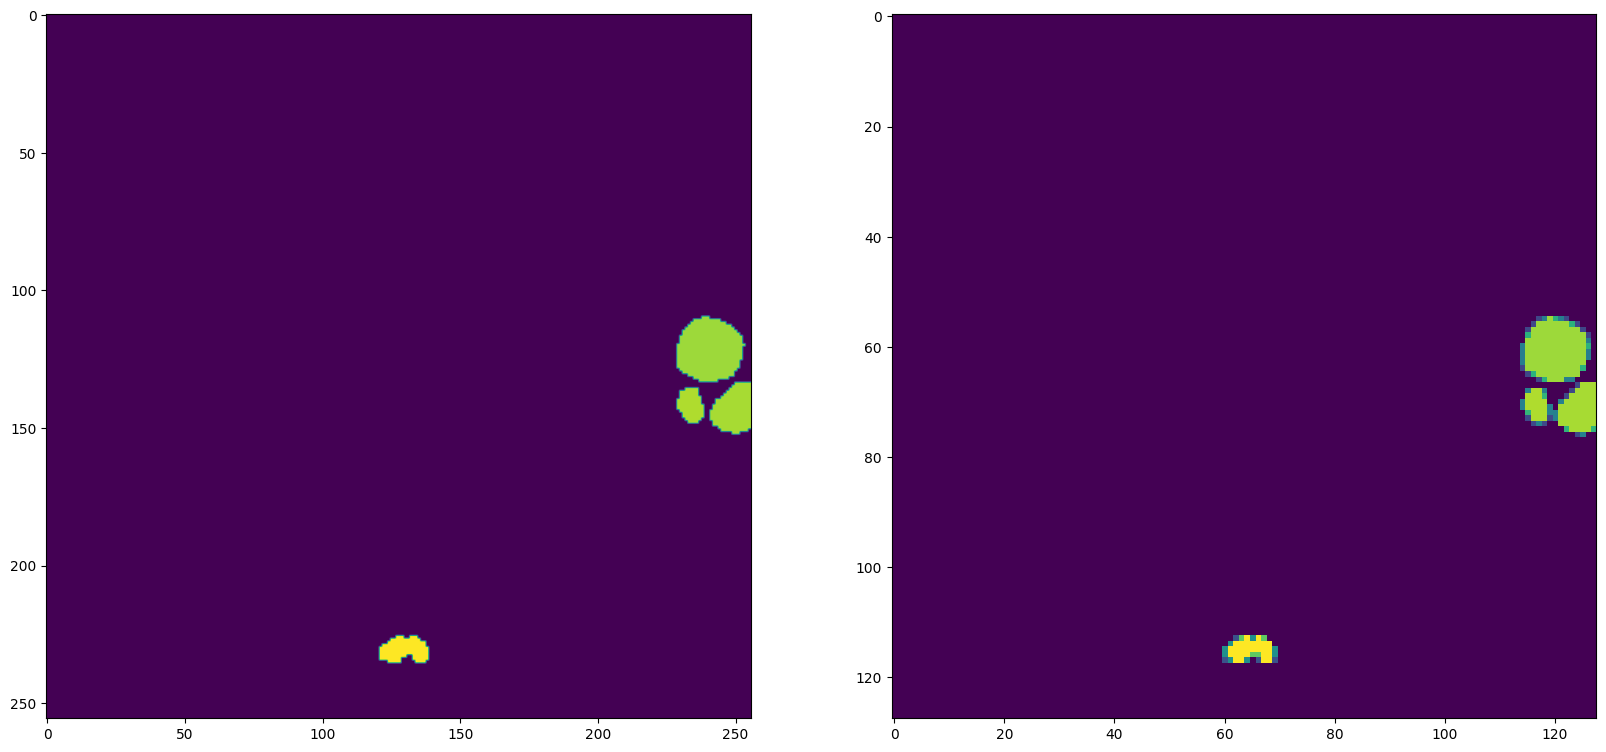

In [19]:
fig, ax = plt.subplots(1,2, figsize=(20,20))
ax[0].imshow(crop_gt)
ax[1].imshow(crop_gt2)